In [ ]:
import os
import shutil

if os.path.exists("logs"):
    shutil.rmtree("logs")
    print("Logs directory cleared")
else:
    print("No logs directory found")

No logs directory found


In [2]:
from utils import start_tensorboard

start_tensorboard()

⚠️  Warning: Logs directory not found at c:\Users\yanni\Dokumente\DSE\dse-sem2\CO2\MachineLearning\lecture-notes-CO2-2026\exercise_3\logs


# Convolutional Neural Networks: Image Classification with CNNs

Moving beyond fully connected networks, we explore Convolutional Neural Networks (CNNs) designed specifically for image data. CNNs preserve spatial structure through convolutional layers, pooling operations, and hierarchical feature learning.


In [ ]:
# load data
import keras
import numpy as np

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()


X_train_scaled = X_train.astype("float32") / 255.0
X_test_scaled = X_test.astype("float32") / 255.0


y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Classes: {np.unique(y_train)}")

X_train: (50000, 32, 32, 3), y_train: (50000,)
X_test: (10000, 32, 32, 3), y_test: (10000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


## The issues with fully connected dense networks for images

As previously discussed, dense networks have a few major downsides as we increase image size and scene complexity. I want you to take a look at what happens to the number of parameters of a dense NN when using the **standard** image size of many more complex datasets, 224x224 pixels. (Quite small by modern standards, right?)

So please everyone build a non-functional model consisting of just an input layer with the flattened dimensions of 224\*224 and a single dense layer of 256 neurons. (Tell me what you see!)

Then think about what happens with convolutional (2D) layers. Does the number of parameters grow in the same way? What about color images?


In [ ]:
from keras.layers import Dense, Input
from keras.models import Model

inputs = Input((224 * 224,))
x = Dense(256, activation="relu")(inputs)
x = Dense(128, activation="relu")(x)
model = Model(inputs=inputs, outputs=x)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,878,208 (49.13 MB)

 Trainable params: 12,878,208 (49.13 MB)

 Non-trainable params: 0 (0.00 B)

## Whats a Convolutional Layer? Whats a Filter?

Some of you may have seen image filters like the Sobel filter already. A (often quadratic) 2d filter is defined. Then this filter slides over the image, where the output is the sum of products of each filter position and its corresponding image position (think dot product!). The thing that makes a Conv2D layer different from a classic filter, is that the filter values are _learned_ (our trainable weights).

We simply define the shape and number of filters in a layer but the exact filter values are learned! Over the course of multiple Conv2D layers, we then expect the layers to learn more complex shapes and patterns to look for in the image, because the receptive field increases. Q: Whats the receptive field?

One thing that is often lost, is that the Convolutional2D layer is not 2d, because it also depends on the number of input channels, e.g. RGB images -> Each filter is how big if 3x3 filters are used?

Each filter also has a bias term!


## Calculate by Hand: CNN Architecture

Lets take a look at a small convolutional neural network and how to think about parameters, as well as input and output shapes for this.

**Task:** Calculate parameters and output shapes for each layer. Does input size affect parameter count?

**Conv2D parameters:** `(kernel_h × kernel_w × input_channels + 1) × filters`

**Output shape:** Depends on kernel size, stride, padding (`same` preserves size, `valid` shrinks).

**Key:** What about different image sizes for inputs? How does the number of parameters change?


| Layer | Input Shape       | Filters (C_out) | Kernel Size | Stride | Padding | Output Shape = ? | Params = ?                    |
| ----- | ----------------- | --------------- | ----------- | ------ | ------- | ---------------- | ----------------------------- |
| Conv1 | 32 × 32 × 3       | 8               | 3 × 3       | 1      | same    | 32 × 32 × 8      | (3 _ 3 _ 3 + 1) \* 8 = 224    |
| Conv2 | (output of Conv1) | 16              | 3 × 3       | 1      | valid   | 30 × 30 × 16     | (3 _ 3 _ 8 + 1) \* 16 = 1,168 |
| Conv3 | (output of Conv2) | 4               | 5 × 5       | 1      | valid   | 26 × 26 × 4      | (5 _ 5 _ 16 + 1) \* 4 = 1,604 |


In [ ]:
from keras.layers import Conv2D

# what about inpout size of images now? does it matter in terms of paramters of our network?
inputs = Input(shape=(32, 32, 3))
x = Conv2D(filters=8, kernel_size=(3, 3), strides=1, padding="same", name="conv1")(
    inputs
)
x = Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding="valid", name="conv3")(x)
outputs = Conv2D(
    filters=4, kernel_size=(5, 5), strides=1, padding="valid", name="conv4"
)(x)
# what exactly is the output of this
model_ = Model(inputs=inputs, outputs=outputs)
model_.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 30, 30, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 26, 26, 4)      │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,996 (11.70 KB)

 Trainable params: 2,996 (11.70 KB)

 Non-trainable params: 0 (0.00 B)

## Add Classification Head

This is fine and all, but how do we actually get this to output probabilities of our classes we want to predict?
For this we introduce a new layer type:

### Flatten Layer

Converts 2D feature maps (height × width × channels) to 1D vector for Dense layers. Example: (24 Height, 24 Width, 64 Feature Maps) → (36864,)= a long 1d feature array. No trainable parameters.
We can then do a typical dense layer to down project into more compact feature representations and finally use the same dense output layer as last time with the fcnn.

What do you notice in terms of parameters now for our final model?


In [ ]:
from keras.layers import Conv2D, Dense, Flatten

inputs = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation="relu")(inputs)
x = Conv2D(64, (3, 3), activation="relu")(x)

# flatten the final feature maps into a 1d feature vector/array
x = Flatten()(x)
x = Dense(128, activation="relu")(x)  # down projection
outputs = Dense(10, activation="softmax")(x)  # 10 classes

model_ = Model(inputs=inputs, outputs=outputs)
model_.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,738,826 (18.08 MB)

 Trainable params: 4,738,826 (18.08 MB)

 Non-trainable params: 0 (0.00 B)

### MaxPooling Layer

Reduces spatial dimensions by taking maximum value in each pooling window. Decreases computation, adds **some minor** translation invariance, controls overfitting.

**Key parameters:**

- `pool_size`: Window size (e.g., (2,2))
- `strides`: Default = pool_size
- `padding`: Usually "valid"

**Effect:** (28, 28, 32) with pool_size=(2,2) → (14, 14, 32). Channels unchanged, spatial dims halved. No trainable parameters.

Question: What happens to the parameter count? Where does the big effect come from?


In [ ]:
from keras.layers import Dropout, GlobalAveragePooling2D, MaxPooling2D

# TODO: Build and compile a CNN for CIFAR-10.
# Requirements:
# - input shape: (32, 32, 3)
# - several Conv2D layers for feature extraction
# - downsampling, for example with MaxPooling2D
# - a classification head that outputs 10 class probabilities
# - compile the model with a suitable optimizer, loss, and accuracy metric
#
# Store the final compiled model in the variable `model`, so the next cells can train it.
inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.summary()

# raise NotImplementedError("Build the CIFAR-10 CNN and assign it to `model`.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3799 - loss: 1.6817 - val_accuracy: 0.5469 - val_loss: 1.2764
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.5286 - loss: 1.3113 - val_accuracy: 0.6143 - val_loss: 1.0926
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6001 - loss: 1.1395 - val_accuracy: 0.6572 - val_loss: 0.9600
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6445 - loss: 1.0208 - val_accuracy: 0.6742 - val_loss: 0.9055
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6701 - loss: 0.9442 - val_accuracy: 0.7057 - val_loss: 0.8441
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6974 - loss: 0.8651 - val_accuracy: 0.7032 - val_loss: 0.8468
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7202 - loss: 0.7970 - val_accuracy: 0.7292 - val_loss: 0.7898
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7387 -

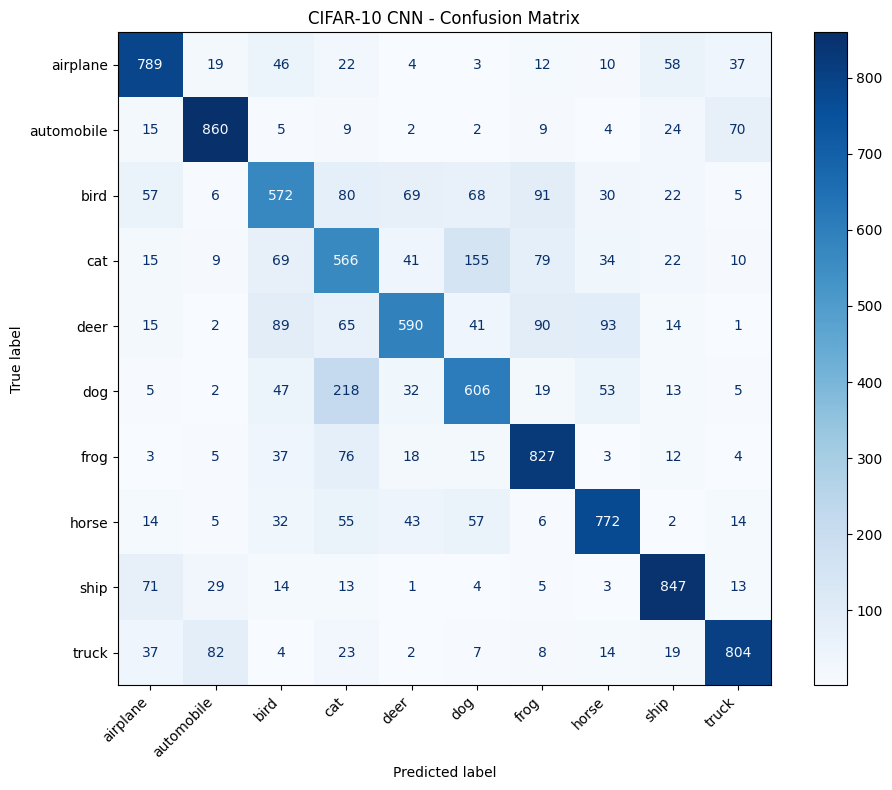

(0.7985771894454956, 0.7232999801635742)

In [9]:
# train and eval on test set
from utils import eval_classification, train_model

basic_cnn_history = train_model(
    model, X_train_scaled, y_train, "basic_Conv_Net_CIFAR10", epochs=10
)
eval_classification(model, X_test_scaled, y_test, class_names, "CIFAR-10 CNN")

## Loading Images from Directories

For datasets that are too large to fit into memory, keep the images on disk in one folder per class and let Keras stream batches from those folders.

CIFAR-10 is small, so here we first write it into the same directory layout: `train/class_name/image.png`, `validation/class_name/image.png`, and `test/class_name/image.png`.


In [10]:
import shutil
from pathlib import Path

from keras.utils import save_img

cifar_dir = Path("data/cifar10_images")
validation_fraction = 0.1
rng = np.random.default_rng(42)

train_indices = []
validation_indices = []
for class_id in np.unique(y_train):
    class_indices = np.where(y_train == class_id)[0]
    rng.shuffle(class_indices)
    n_validation = int(len(class_indices) * validation_fraction)
    validation_indices.extend(class_indices[:n_validation])
    train_indices.extend(class_indices[n_validation:])

splits = {
    "train": (X_train[train_indices], y_train[train_indices]),
    "validation": (X_train[validation_indices], y_train[validation_indices]),
    "test": (X_test, y_test),
}

if cifar_dir.exists():
    shutil.rmtree(cifar_dir)


for split_name in splits:  # forr train, val and test
    for class_name in class_names:  # for airplane, truck, car ...
        (cifar_dir / split_name / class_name).mkdir(
            parents=True, exist_ok=True
        )  # make a folder to save the images

for split_name, (images, labels) in splits.items():
    for i, (image, label) in enumerate(zip(images, labels)):
        image_path = (
            cifar_dir / split_name / class_names[int(label)] / f"{i:05d}.png"
        )  # eg cifar10/train/airplane/00001.png
        save_img(image_path, image)

print(f"CIFAR-10 directory dataset ready at: {cifar_dir}")

CIFAR-10 directory dataset ready at: data\cifar10_images


In [11]:
import tensorflow as tf

batch_size = 64
img_size = (32, 32)

train_ds = keras.utils.image_dataset_from_directory(
    cifar_dir / "train",
    class_names=class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)

validation_ds = keras.utils.image_dataset_from_directory(
    cifar_dir / "validation",
    class_names=class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    cifar_dir / "test",
    class_names=class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
)

rescale = keras.layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda images, labels: (rescale(images), labels)).prefetch(
    tf.data.AUTOTUNE
)  # prefetch the next batch WHILE we are training on the current one so we use CPU and GPU
validation_ds = validation_ds.map(
    lambda images, labels: (rescale(images), labels)
).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda images, labels: (rescale(images), labels)).prefetch(
    tf.data.AUTOTUNE
)

Found 45000 files belonging to 10 classes.
Found 5000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Data Augmentation


For most modern networks that are actually used in production, architecture is not the defining factor - high quality data, and how well it captures the real world problem, is. Often the process of sampling data, getting images etc. is expensive and we cant always have the amount of data we need to train a NN well.

One mitigation in computer vision is a set data augmentation strategies that mostly consist of **simple affine tranformations** of our input images. This is often:

- Random Crop, Flip, Zoom
- Random Translation (shifting)
- Color or Brightness Jitter

**The cool thing is that we apply those tranformations dynamically to each new batch randomly.**

Lets look at how keras does this with a set of augmentation layers.

NOTE: When we choose augmentations we should always think about what makes sense in a real world setting - which augmentations could exist when we use the model later for prediction? (e.g. compare Horizontal vs Vertical Flip)

https://keras.io/api/layers/preprocessing_layers/


In [13]:
data_augmentation = keras.Sequential(
    [
        ##TODO Use various agumentation layer
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
    ]
)

sample_images, sample_labels = next(iter(train_ds))
augmented_images = data_augmentation(sample_images[:12], training=True)

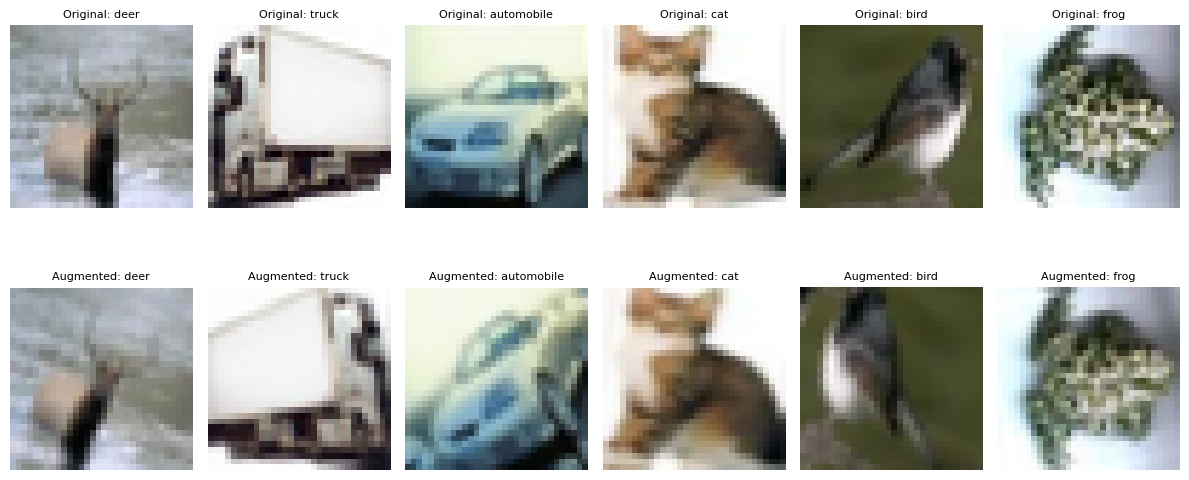

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(12, 6))
for i in range(6):
    label = int(sample_labels[i])

    axes[0, i].imshow(sample_images[i])
    axes[0, i].set_title(f"Original: {class_names[label]}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(augmented_images[i])
    axes[1, i].set_title(f"Augmented: {class_names[label]}", fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
# TODO: Build, compile, train, and evaluate a CNN that uses `data_augmentation`.
# Requirements:
# - start with Input(shape=(32, 32, 3))
# - apply `data_augmentation` inside the model before the convolutional feature extractor
# - use a CNN architecture suitable for CIFAR-10 classification
# - output 10 class probabilities
# - compile, train on `train_ds`, validate on `validation_ds`, and evaluate on `test_ds`
#
# Store the final compiled model in the variable `model_aug`.

# build CNN model with data augmentation
inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation="softmax")(x)
model_aug = Model(inputs=inputs, outputs=outputs)
model_aug.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile
model_aug.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Train
history_aug = model_aug.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )
    ],
)

# Evaluate
test_loss, test_accuracy = model_aug.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}\n")
print(f"Test Loss: {test_loss:.4f}\n\n")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 83ms/step - accuracy: 0.3681 - loss: 1.7338 - val_accuracy: 0.5000 - val_loss: 1.3568
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4898 - loss: 1.4233 - val_accuracy: 0.5938 - val_loss: 1.1455
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5440 - loss: 1.2872 - val_accuracy: 0.6096 - val_loss: 1.1255
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5796 - loss: 1.1972 - val_accuracy: 0.6288 - val_loss: 1.0818
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6046 - loss: 1.1370 - val_accuracy: 0.6890 - val_loss: 0.8948
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6241 - loss: 1.0846 - val_accuracy: 0.6956 - val_loss: 0.8661
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6365 - loss: 1.0411 - val_accuracy: 0.6944 - val_loss: 0.8656
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6529 - loss: 1.0025 - 

## Larger Custom CNN

Now we train the larger custom CNN from the previous notebook on the directory-backed datasets. The architecture is the same, except the last convolution block gets a projection shortcut before the activation.


In [20]:
# TODO: Build a stronger custom CNN for CIFAR-10.
# Ideas to try:
# - more convolutional blocks than the basic model
# - Dropout for more stable training and regularization
# - optional residual/skip connections
# - optional data augmentation and rescaling inside the model
# - compare the result against the basic CNN
#
# Store the final compiled model in the variable `model_large` and train/evaluate it.
inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation="softmax")(x)
model_large = Model(inputs=inputs, outputs=outputs)
model_large.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,386 (2.49 MB)

 Trainable params: 653,386 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compile
model_large.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Train
history_large = model_large.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=25,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ],
)

# Evaluate
test_loss, test_accuracy = model_large.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}\n")
print(f"Test Loss: {test_loss:.4f}\n\n")

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.3658 - loss: 1.7207 - val_accuracy: 0.4900 - val_loss: 1.3782
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5194 - loss: 1.3400 - val_accuracy: 0.6078 - val_loss: 1.1018
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5817 - loss: 1.1828 - val_accuracy: 0.6250 - val_loss: 1.0424
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6207 - loss: 1.0879 - val_accuracy: 0.6664 - val_loss: 0.9414
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6476 - loss: 1.0118 - val_accuracy: 0.6850 - val_loss: 0.9077
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.6692 - loss: 0.9537 - val_accuracy: 0.6934 - val_loss: 0.8861
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6849 - loss: 0.9123 - val_accuracy: 0.7322 - val_loss: 0.7530
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6988 - loss: 0.8703 - 

## Transfer Learning

We might be quicker than the VL with this, however its quite a powerful concept and it fits here. Transfer learning is the technique of using a _large_ pretrained network (usually not by us) as a base model, and simply adapting the output layers to our needs. The weights of the model stump or base can be _frozen_.

What does that mean? How does it help?


In [22]:
# import the base model
base_model = keras.applications.EfficientNetV2B0(
    include_top=False, weights="imagenet", input_shape=(32, 32, 3), pooling=None
)

base_model.trainable = True
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = base_model(x, training=True)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation="softmax")(x)
model_effnet = Model(inputs=inputs, outputs=outputs)
model_effnet.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_effnet.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1, 1, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,281,434 (23.96 MB)

 Trainable params: 6,220,826 (23.73 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [23]:
from utils import eval_classification, train_model

effnet_history = train_model(
    model_effnet, X_train, y_train, "effnetb0_cifar10", epochs=25
)
eval_classification(
    model_effnet, X_test, y_test, class_names, "CIFAR-10 EfficientNetB0"
)

Epoch 1/25
  94/1250 ━━━━━━━━━━━━━━━━━━━━ 3:10 164ms/step - accuracy: 0.1873 - loss: 2.2752

KeyboardInterrupt: 